# NumPy Kütüphanesi Neden Bu Kadar Popüler?

`Numpy`, bizler için onu normal Python'un çok ötesine taşıyan birçok işlevi olan harika bir kütüphanedir. Birazdan NumPy'ın her zaman kullandığımız bazı temel işlevlere odaklanacağız. 

Ama başlamadan önce, Pandas kütüphanesiyle birçok yönden sütun adları (ve bazı SQL yapıları) ile oldukça uyumlu bir şekilde çalışabildiğini unutmayın! Yani, Numpy dizisine yapabileceğimiz her şeyi genellikle bir Pandas sütunu üzerinde de yapabiliriz. 

**Bir İstisna:** Pandas kütüphanesinde matris işlemlerde NumPy kütüphanesinde olduğu kadar iyi çalışmıyor...

## Bazı Örnek Veriler Oluşturalım

Eğer gerekliyse, başlamadan önce `NumPy` kütüphanesini bilgisayarımıza yükleyelim...

```python
!pip install numpy
```

In [1]:
import numpy as np # Bilgisayara yüklediğimiz kütüphaneleri kullanmak için bu yapıyı kullanıcaz

In [2]:
data = np.random.uniform(size=10000)
data_as_list = data.tolist()

In [3]:
data_as_list

[0.09210461570885342,
 0.05210019784641107,
 0.3745723963513019,
 0.5363911979976441,
 0.17456061328402006,
 0.9920806886640798,
 0.6824724716484517,
 0.4508415417995796,
 0.8437724462840875,
 0.938224620933317,
 0.08238693898990435,
 0.026963825128099472,
 0.7295260368891774,
 0.9079570703516568,
 0.17574483626508097,
 0.7897141072310015,
 0.13379284249094925,
 0.06011669624865479,
 0.805652206916136,
 0.4820529714367954,
 0.5673419940158115,
 0.2102629278823982,
 0.2676288213294612,
 0.20248765036145766,
 0.7485026438600844,
 0.3113821668425806,
 0.9907232046401685,
 0.635957268594004,
 0.768350761252473,
 0.6381303000379208,
 0.8966258414680074,
 0.8069200021935258,
 0.9774391793981264,
 0.22074685045035403,
 0.8715868932686088,
 0.8668636407984742,
 0.70291016747664,
 0.5233829289496941,
 0.8473267680410577,
 0.39145906953537213,
 0.17499867348985298,
 0.2130575981518208,
 0.057194206325926644,
 0.5789718691777539,
 0.8775243030257343,
 0.9693927329896841,
 0.9196362516392164,
 0.3

In [4]:
data.shape

(10000,)

In [5]:
type(data)

numpy.ndarray

Bir liste yapısı üzerinde matematiksel bir işlem yapmak istiyorsak, listede açık bir şekilde döngü yapısı kurmamız gerekir. Ancak bir numpy dizisi üzerinde hareket etmek istiyorsak, ona tek bir nesne gibi davranabiliriz ve işlem numpy dizilerini oluşturan **tüm elemanlar** üzerinden gerçekleştirilir. 
- Hem de **ışık hızında...**

In [6]:
new_data = data + 2

In [7]:
for added, raw in zip(new_data[:10],data):
    print(added, raw)

2.0921046157088536 0.09210461570885342
2.052100197846411 0.05210019784641107
2.3745723963513017 0.3745723963513019
2.536391197997644 0.5363911979976441
2.17456061328402 0.17456061328402006
2.99208068866408 0.9920806886640798
2.6824724716484516 0.6824724716484517
2.4508415417995795 0.4508415417995796
2.8437724462840874 0.8437724462840875
2.938224620933317 0.938224620933317


**"Işık hızında"** yı biraz daha açmak gerekirse?

In [8]:
%%timeit
new_list = [x+2 for x in data_as_list]

588 µs ± 42.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [9]:
%%timeit
new_data2 = data + 2

4.1 µs ± 169 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## Filtreleme

Pandas kütüphanesiyle ilgili harika özelliklerden biri, verilerinizi hızlı bir şekilde filtreleme yeteneğidir. Bu hızlı filtreleme yeteneğini arka planında ise Numpy dizileriyle çalışmasına borçludur. Hadi numpy dizilerde filtrelemeyi inceleyelim.
- Bunu yaparken bir koşul oluşturacağımızı ve dizideki her değerin, koşulun gerçekten sağlanıp sağlanmadığına bağlı olarak `True` veya `False` olacağını unutmayın.

In [10]:
new_data > 2.5

array([False, False, False, ..., False, False,  True])

Filtreleme işleminden sonra belirlediğimiz değerin üstünde olan değerler `True`, altında olan değerler ise `False` döndürdüler.
- Ama kaç tanesi?

In [11]:
np.sum(new_data > 2.5)

5063

In [12]:
new_data[new_data > 2.5].shape

(5063,)

- Peki filtreleme işlemime uyan değerleri görmek istesem?

In [13]:
new_data[new_data > 2.5]

array([2.5363912 , 2.99208069, 2.68247247, ..., 2.71656508, 2.83541681,
       2.97343051])

Ayrıca, filtrelediğimiz verilerle aynı uzunluğa sahip herhangi bir veri kaynağına da filtre uygulayabiliriz.

- Örneğin, veriler üzerinde `new_data-2`'ye eşdeğer bir koşul yaparsak, yine `new_data` aynı şekilde filtreleyebiliriz.

Bu mümkündür çünkü veriler **aynı uzunluktadır**.

In [14]:
new_data[new_data-2 > 0.5]

array([2.5363912 , 2.99208069, 2.68247247, ..., 2.71656508, 2.83541681,
       2.97343051])

## Düzenleme

`Numpy` ayrıca dizinizi hızlı bir şekilde düzenlememizi sağlar.
- **İndexlerin nasıl hizalanacağının** bir listesini sağlayarak verileri kolaylıkla yeniden düzenleyebiliriz.

In [15]:
a = np.array([10,20,30,40,50])
a[[1,0,2,3,4]]

array([20, 10, 30, 40, 50])

## Numpy Kullanarak Oluşturabildiğimiz Dizileri Biraz Daha Detaylı İnceleyelim

`Numpy` rastgele sayıları etkili bir şekilde üretmek için harika araçlara sahiptir. 
- Hadi bunları biraz daha keşfedelim (görselleştirme yöntemlerini ilerleyen derslerde daha detaylı inceleyeceğiz).

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("seaborn")

def plot_hist(x, bins=None):
    plt.figure(dpi=100)
    plt.hist(x, bins=bins);

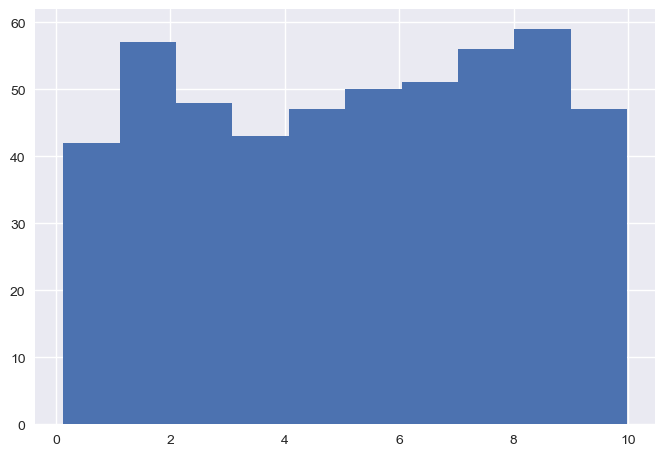

In [17]:
x = np.random.uniform(0,10,size=500)
plot_hist(x)    

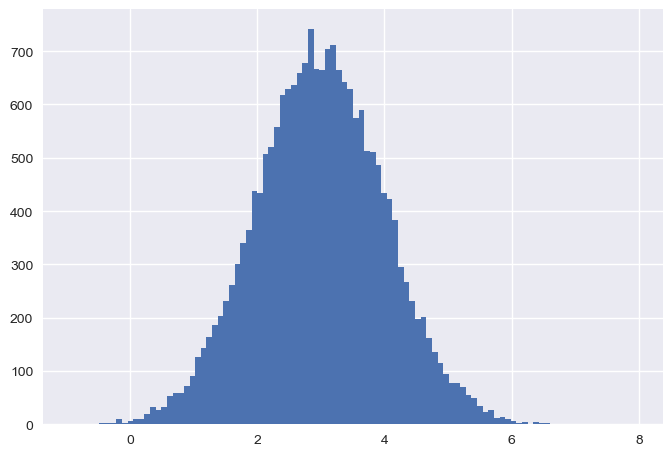

In [18]:
x = np.random.normal(3,1,size=20000)
plot_hist(x, bins=100)

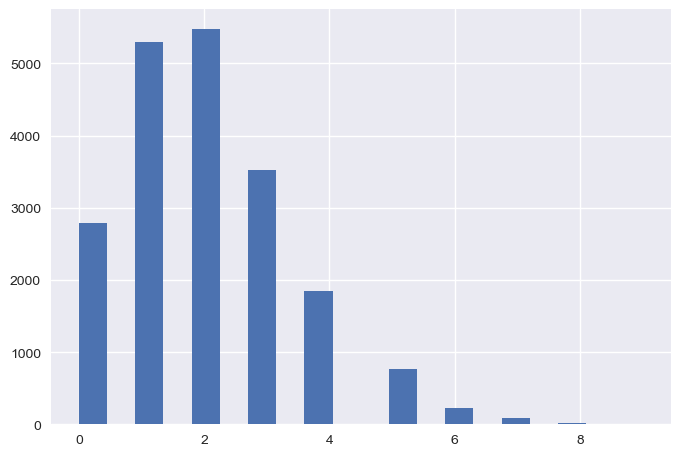

In [19]:
x = np.random.poisson(2, size=20000)
plot_hist(x, bins=20)

## Matris İşlemleri

Matris işlemlerini `python` da yapmak için bazı kodlar yazmaya ihtiyaç duyarız. Ancak `numpy` bize "matris çarpımı" gibi işlemleri gerçekleştirmede büyük kolaylık sağlar.
- Bir örnek üzerinden görelim.

In [20]:
mat_a = np.random.uniform(size=(2,4))
mat_b = np.random.uniform(size=(4,3))

mat_a

array([[0.31661677, 0.15898237, 0.21057823, 0.73296569],
       [0.25413404, 0.6631217 , 0.17562191, 0.50135695]])

In [21]:
mat_a@mat_b # @ işareti numpy da matris çarpımını ifade eder

array([[0.83171457, 0.53525889, 0.71945189],
       [0.99278234, 0.54482379, 0.77195836]])

Ayrıca yapamayacağı bir işlemde de bize hata verir.

- Örnek olarak `mat_b@mat_a` deneyelim.

In [22]:
mat_b@mat_a

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

Bu çarpma işlemini yapmak için `np.dot` da kullanabiliriz. Bununla birlikte, vektörlerin gerçek nokta çarpımını da hesapladığı için buna dikkat edin. Bunu nasıl yaptığı konusunda akıllı olmaya çalışır, bu nedenle genellikle iyi bir iş çıkarır.

In [23]:
np.dot(mat_a, mat_b)

array([[0.83171457, 0.53525889, 0.71945189],
       [0.99278234, 0.54482379, 0.77195836]])

Vektör çarpımı örneği de görelim...

In [24]:
a = np.array([1,2,3])
b = np.array([4,5,6])
np.dot(a,b)

32

`Numpy` ayrıca **transpoze** vb. gibi temel matris öğelerini de bilir. Ayrıca `np.linalg` altında bir sürü harika lineer cebir malzemesine sahiptir, ancak şimdilik bu konuyu burada noktayalım.

In [25]:
mat_a

array([[0.31661677, 0.15898237, 0.21057823, 0.73296569],
       [0.25413404, 0.6631217 , 0.17562191, 0.50135695]])

In [26]:
mat_a.T

array([[0.31661677, 0.25413404],
       [0.15898237, 0.6631217 ],
       [0.21057823, 0.17562191],
       [0.73296569, 0.50135695]])

## Vektörler Üzerinde İşlemler

İşte bu yüzden `numpy` matematiksel işlemlerde kraldır. Pek çok ortak şeyi alabilir ve bunları "vektörleştirilmiş" bir sürece dönüştürebiliriz. 
- Örneğin, bir önceki oluşturduğumuz matrise bir vektör eklemeye çalışalım... (bu vektörü her satıra ekleyeceğiz)

In [27]:
mat_a.T + np.array([1,2])

array([[1.31661677, 2.25413404],
       [1.15898237, 2.6631217 ],
       [1.21057823, 2.17562191],
       [1.73296569, 2.50135695]])

`Numpy` sütun uzunluklarının eşleştiğini ve tüm vektörleri eklemek için otomatik olarak ayarlandığını rahatlıkla fark edebilir.

In [28]:
mat_a - np.array([1,2,3,4])

array([[-0.68338323, -1.84101763, -2.78942177, -3.26703431],
       [-0.74586596, -1.3368783 , -2.82437809, -3.49864305]])

Bu özelliği bir vektörle, bir vektör tablosu arasındaki mesafeyi hesaplarken de kullanabiliriz.

In [29]:
# Vektör tanımlamaları
new_vec = np.array([1,2])
all_vecs = np.random.uniform(size=(100,2))

Eğer tek bir vektör çifti üzerinden bu işlemi gerçekleştirirsek;

In [30]:
x = all_vecs[0]
np.sqrt((new_vec[0] - x[0])**2 + (new_vec[1] - x[1])**2) # 2 vektör arasındaki mesafe

1.4199011372195562

Şimdi hadi 10 vektör çifti üzerinde aynı işlemi uygulayalım;

In [31]:
np.sqrt(np.sum((all_vecs - new_vec)**2, axis=1))[:10]

array([1.41990114, 1.25638472, 1.98727958, 1.95048913, 1.52741076,
       1.61434828, 1.7234812 , 1.25532722, 1.66597538, 2.19005719])

`Numpy` kütüphanesi kullanarak yapılan bu işlemler **büyük veri kümelerinde ciddi bir zaman tasarrafu** sağlar. Nasıl mı?

In [32]:
%%timeit
output = []
for x in all_vecs:
    dist = np.sqrt((new_vec[0] - x[0])**2 + (new_vec[1] - x[1])**2)
    output.append(dist)

651 µs ± 15.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [33]:
%%timeit
np.sqrt(np.sum((all_vecs - new_vec)**2, axis=1))

9.58 µs ± 187 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


- **1 µs** (mikro-saniye) = **1000 ns** (nano-saniye) eşit olduğunu göz önünde bulunduralım!

Ya veri kümesinin boyutunu daha da arttırırsak?

In [34]:
all_vecs = np.random.uniform(size=(10000,2))

In [35]:
%%timeit
output = []
for x in all_vecs:
    dist = np.sqrt((new_vec[0] - x[0])**2 + (new_vec[1] - x[1])**2)
    output.append(dist)

62.6 ms ± 1.73 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [36]:
%%timeit
np.sqrt(np.sum((all_vecs - new_vec)**2, axis=1))

167 µs ± 4.56 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


- **1 µs** (mikro-saniye) = **1000 ms** (mili-saniye) eşit olduğunu göz önünde bulunduralım!

`Numpy` dizilerinin hızına her beraber şahit olduk. Son olarak ise şu ana kadar konuştuklarımızı bir grafik gösterimi üzerinde toparlayalım...

#### NumPy Dizilerinden Yararlanarak Vektörler Arası Mesafe Hesabı

In [37]:
import time
list_timing = []
for num_vecs in np.linspace(10,10000,100):
    all_vecs = np.random.uniform(size=(int(num_vecs),2)).tolist()
    # İşlemin başladığı zaman
    start = time.time()
    
    # Vektörler arası mesafe
    output = []
    for x in all_vecs:
        dist = np.sqrt((new_vec[0] - x[0])**2 + (new_vec[1] - x[1])**2)
        output.append(dist)
        
    # İşlem tamamlanana kadar ne kadar süre geçti
    end = time.time()
    list_timing.append((num_vecs, end - start))

#### Listelerden Yararlanarak Vektörler Arası Mesafe Hesabı

In [38]:
array_timing = []
for num_vecs in np.linspace(10,10000,100):
    all_vecs = np.random.uniform(size=(int(num_vecs),2))
    # İşlemin başladığı zaman
    start = time.time()
    
    # Vektörler arası mesafe
    output = np.sqrt(np.sum((all_vecs - new_vec)**2, axis=1))

    # İşlem tamamlanana kadar ne kadar süre geçti
    end = time.time()
    array_timing.append((num_vecs, end - start))

Vee sonuç...

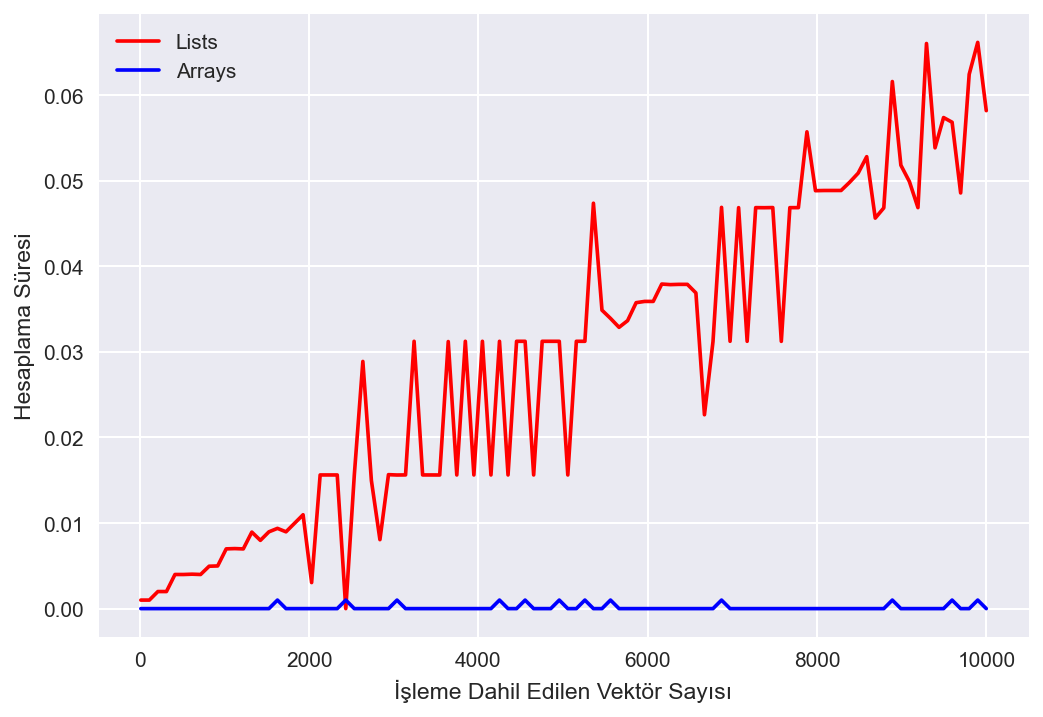

In [39]:
plt.figure(dpi=150)
list_X, list_times = zip(*list_timing)
array_X, array_times = zip(*array_timing)

plt.plot(list_X, list_times, 'r', label="Lists")
plt.plot(array_X, array_times,'b', label='Arrays')
plt.xlabel("İşleme Dahil Edilen Vektör Sayısı")
plt.ylabel("Hesaplama Süresi")
plt.legend();